# NFXP — Empirical Application: Original Dynamic Demand Model

**Oliver Ovdal Eiberg Jørgensen & Solveig Røndal-Liniger** — Dynamic Programming, Spring 2026

---

## Model

This notebook estimates the empirical counterpart of `nfxp_original.ipynb` on the Netto scanner panel. In each period $t$, consumer $i$ chooses $y_{it} \in \{0,1,\ldots,J\}$: either no purchase ($y=0$) or brand $j \in \{1,\ldots,J\}$.

**State variable:** $x_{it}=(\ell_{it},\,d_{it},\,e_t)$ where
- $\ell_{it}$: last-purchased brand
- $d_{it}$: weeks since the last purchase
- $e_t$: observed promotion status, represented as a finite Markov state

**Utility:**
$$
U_{it} = \begin{cases}
  \alpha(\ell_{it}) - \beta^{\rm dep}\cdot d_{it} & \text{if } y_{it}=0, \\
  \alpha(j) - \gamma\cdot p_t(j) - \beta^{\rm sc}\mathbf{1}\{\ell_{it}\neq j\} & \text{if } y_{it}=j.
\end{cases}
$$

- $\alpha_1=0$ normalizes Brand 1 as the reference alternative; $\alpha_2$ is Brand 2 preference relative to Brand 1
- $\gamma\cdot p_t(j)$ is disutility from expenditure
- $\beta^{\rm dep}\cdot d_{it}$ makes the no-purchase option less attractive as inventory is depleted over time
- $\beta^{\rm sc}$ is a symmetric cost of switching brands

**Transition rule:**
$$
(\ell_{i,t+1},\,d_{i,t+1}) = \begin{cases}
  (\ell_{it},\,d_{it}+1) & \text{if } y_{it}=0, \\
  (j,\,1) & \text{if } y_{it}=j.
\end{cases}
$$

The empirical application carries over the same utility and transition structure as the Monte Carlo notebook. Its inputs are empirical: the promotion transition matrix and state-contingent prices are constructed from observed weekly data, and observed consumer histories replace simulated panels.

**Estimated structural parameters:**
$$
\theta = [\alpha_2,\;\gamma,\;\beta^{\rm dep},\;\beta^{\rm sc}], \qquad \alpha_1=0.
$$

**Estimator:** NFXP, using VFI in the inner loop and a grid-initialized bounded L-BFGS-B maximization of the empirical log-likelihood in the outer loop.


## 1. Import

In [ ]:
import time                            
import numpy as np                      
import pandas as pd                
from scipy.optimize import minimize_scalar, minimize  
from scipy.stats import norm, chi2       
import matplotlib.pyplot as plt      

## 2. Model configuration

In [ ]:
J         = 2       # number of brands
D_MAX     = 25      # maximum duration in weeks
DELTA     = 0.95    # discount factor
N_CHOICES = J + 1   # no purchase plus brand choices

EMPIRICAL_BRANDS        = [1, 2]  # estimated brand alternatives
EMPIRICAL_PRICE_COLUMNS = {1: "Brand_1_price", 2: "Brand_2_price"}  # price columns

# Inner-loop and transition settings.
VFI_TOL      = 1e-10  # VFI convergence tolerance
VFI_MAXITER  = 2_000  # VFI iteration limit
TRANS_SMOOTH = 1e-3   # transition-count smoothing

# Promotion states
promo_states = np.array(
    [[(s >> j) & 1 for j in range(J)] for s in range(2 ** J)], dtype=int
)
N_PROMO = len(promo_states)  # number of promotion states

print(f"J={J}, D_MAX={D_MAX}, N_CHOICES={N_CHOICES}, N_PROMO={N_PROMO}")
print("Promotionstilstande:", promo_states)

J=2, D_MAX=25, N_CHOICES=3, N_PROMO=4
Promotionstilstande: [[0 0]
 [1 0]
 [0 1]
 [1 1]]


## 3. Data Inputs and data clean up

In [35]:

# Data path
SCANNER_DATA     = "/Users/solveigroendalliniger/Desktop/netto_df.csv"  # panel data of choices
PRICE_PROMO_DATA = "/Users/solveigroendalliniger/Desktop/Price_Promo.xlsx"  # weekly price data

# Loading data 
netto_df = pd.read_csv(SCANNER_DATA)

# Clean column names
netto_df.columns = netto_df.columns.astype(str).str.strip()

# Drop week 53.
netto_df = netto_df[netto_df["week_num"] != 53].copy()

# Creating the correct data types
netto_df["Brand"] = netto_df["Brand"].astype(str)

netto_df["Price"] = pd.to_numeric(
    netto_df["Price"],
    errors="coerce"
).round(1)

netto_df["Customer_ID"] = pd.to_numeric(
    netto_df["Customer_ID"],
    errors="coerce"
).astype("Int64")

netto_df["week_num"] = pd.to_numeric(
    netto_df["week_num"],
    errors="coerce"
).astype("Int64")

netto_df["brand_id"] = pd.to_numeric(
    netto_df["Brand"],
    errors="coerce"
).fillna(0).astype(int)


# Loading price data 
price_promo_workbook = pd.ExcelFile(PRICE_PROMO_DATA)

print("Sheets in Price_Promo.xlsx:")
print(price_promo_workbook.sheet_names)

# Selecting the correct sheet
price_promo_sheet_name = price_promo_workbook.sheet_names[2]
print(f"\nUsing sheet: {price_promo_sheet_name}")

price_promo_df = pd.read_excel(
    price_promo_workbook,
    sheet_name=price_promo_sheet_name
)

# Clean column names
price_promo_df.columns = price_promo_df.columns.astype(str).str.strip()


# Required columns
price_promo_required_columns = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Promo_Brand_1",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Promo_Brand_2",
]



# Cleaning promo data 
for col in price_promo_required_columns:
    price_promo_df[col] = pd.to_numeric(
        price_promo_df[col],
        errors="coerce"
    )

price_promo_df = price_promo_df.dropna(subset=["WeekNum"]).copy()
price_promo_df["WeekNum"] = price_promo_df["WeekNum"].astype(int)


# Promo indicators 
price_promo_df["Promo_Brand_1"] = (
    price_promo_df["Promo_Brand_1"]
    .fillna(0)
    .astype(int)
)

price_promo_df["Promo_Brand_2"] = (
    price_promo_df["Promo_Brand_2"]
    .fillna(0)
    .astype(int)
)


# Creating mean sales prices for simplicty in the estimation
mean_discount_brand_1 = price_promo_df.loc[
    (price_promo_df["Promo_Brand_1"] == 1) &
    (price_promo_df["Discount_Brand_1"].notna()),
    "Discount_Brand_1"
].mean()

if not np.isfinite(mean_discount_brand_1):
    mean_discount_brand_1 = price_promo_df["Discount_Brand_1"].mean()

if not np.isfinite(mean_discount_brand_1):
    mean_discount_brand_1 = price_promo_df["RRP_Brand_1"].median()

mean_discount_brand_2 = price_promo_df.loc[
    (price_promo_df["Promo_Brand_2"] == 1) &
    (price_promo_df["Discount_Brand_2"].notna()),
    "Discount_Brand_2"
].mean()

if not np.isfinite(mean_discount_brand_2):
    mean_discount_brand_2 = price_promo_df["Discount_Brand_2"].mean()

if not np.isfinite(mean_discount_brand_2):
    mean_discount_brand_2 = price_promo_df["RRP_Brand_2"].median()


# Store the mean sale prices.
price_promo_df["Mean_Discount_Brand_1"] = mean_discount_brand_1
price_promo_df["Mean_Discount_Brand_2"] = mean_discount_brand_2


# Construct the offered-price columns used in the merge.
price_promo_df["Brand_1_price"] = np.where(
    price_promo_df["Promo_Brand_1"] == 1,
    mean_discount_brand_1,
    price_promo_df["RRP_Brand_1"]
)

price_promo_df["Brand_2_price"] = np.where(
    price_promo_df["Promo_Brand_2"] == 1,
    mean_discount_brand_2,
    price_promo_df["RRP_Brand_2"]
)


# Prices data 
empirical_binary_price_summary = pd.DataFrame(
    [
        {
            "Brand": 1,
            "RRP median": price_promo_df["RRP_Brand_1"].median(),
            "Mean sale price": mean_discount_brand_1,
            "Promo weeks": int(price_promo_df["Promo_Brand_1"].sum()),
        },
        {
            "Brand": 2,
            "RRP median": price_promo_df["RRP_Brand_2"].median(),
            "Mean sale price": mean_discount_brand_2,
            "Promo weeks": int(price_promo_df["Promo_Brand_2"].sum()),
        },
    ]
)

print("\nBinary empirical price support:")
print(
    empirical_binary_price_summary.to_string(
        index=False,
        float_format=lambda x: f"{x:.3f}"
    )
)


print("Price/promo preview:")
print(
    price_promo_df[
        [
            "WeekNum",
            "RRP_Brand_1",
            "Promo_Brand_1",
            "Brand_1_price",
            "RRP_Brand_2",
            "Promo_Brand_2",
            "Brand_2_price",
        ]
    ]
    .head(10)
)
# Removing columns 
old_price_promo_cols = [
    "WeekNum",
    "RRP_Brand_1",
    "Discount_Brand_1",
    "Mean_Discount_Brand_1",
    "Promo_Brand_1",
    "Brand_1_price",
    "RRP_Brand_2",
    "Discount_Brand_2",
    "Mean_Discount_Brand_2",
    "Promo_Brand_2",
    "Brand_2_price",
]

# Remove suffix columns left by earlier merges.
old_price_promo_cols_extended = old_price_promo_cols.copy()

for col in old_price_promo_cols:
    old_price_promo_cols_extended.append(f"{col}_x")
    old_price_promo_cols_extended.append(f"{col}_y")

netto_df = netto_df.drop(
    columns=[col for col in old_price_promo_cols_extended if col in netto_df.columns]
)

# Merge scanner data and prices data together 
netto_df = netto_df.merge(
    price_promo_df[price_promo_merge_columns],
    left_on="week_num",
    right_on="WeekNum",
    how="left",
    validate="many_to_one"
)


# Safety check for rows with no prices 
netto_df = netto_df.loc[
    netto_df["Brand_1_price"].notna() &
    netto_df["Brand_2_price"].notna()
].copy()

display(netto_df.head())

Sheets in Price_Promo.xlsx:
['_com.sap.ip.bi.xl.hiddensheet', 'Sheet1', 'Sheet2', 'Sheet3']

Using sheet: Sheet2

Binary empirical price support:
 Brand  RRP median  Mean sale price  Promo weeks
     1      24.950            9.842           10
     2      11.950            9.993            6
Price/promo preview:
   WeekNum  RRP_Brand_1  Promo_Brand_1  Brand_1_price  RRP_Brand_2  \
0        1        24.95              0      24.950000        11.95   
1        2        24.95              0      24.950000        11.95   
2        3        24.95              0      24.950000        11.95   
3        4        24.95              0      24.950000        11.95   
4        5        24.95              0      24.950000        11.95   
5        6        24.95              0      24.950000        11.95   
6        7        24.95              0      24.950000        11.95   
7        8        24.95              1       9.842316        11.95   
8        9        24.95              0      24.950000   

,Unnamed: 0,Customer_ID,week_num,y,Brand,Quantity,promo_flag,Price,last_purchase_week,duration,...,RRP_Brand_1,Discount_Brand_1,Mean_Discount_Brand_1,Promo_Brand_1,Brand_1_price,RRP_Brand_2,Discount_Brand_2,Mean_Discount_Brand_2,Promo_Brand_2,Brand_2_price
0,1,1,1,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
1,2,1,2,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
2,3,1,3,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
3,4,1,4,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95
4,5,1,5,0,0,0,0,NaN,NaN,NaN,...,24.95,NaN,9.842316,0,24.95,11.95,NaN,9.99284,0,11.95


## 4. Empirical Price Process


In [ ]:
# Function to create a joint promo indicator 
def empirical_promo_idx(frame: pd.DataFrame) -> np.ndarray:
    """Map promotion indicators to a joint state index."""
    mat = frame[[f"Promo_Brand_{b}" for b in EMPIRICAL_BRANDS]].fillna(0).astype(int).to_numpy()
    return mat @ (2 ** np.arange(J))


# Collapse the panel to one price and promotion row per week.
def build_weekly_state_table(data: pd.DataFrame) -> pd.DataFrame:
    weekly = (
        data[["week_num", "Brand_1_price", "Brand_2_price", "Promo_Brand_1", "Promo_Brand_2"]]
        .dropna().drop_duplicates().sort_values("week_num").reset_index(drop=True)
    )
    weekly["promo_idx"] = empirical_promo_idx(weekly)
    return weekly


# Estimate promotion-state transition probabilities.
def estimate_promo_transition(weekly: pd.DataFrame, smoothing=TRANS_SMOOTH) -> np.ndarray:
    idx = weekly["promo_idx"].to_numpy(dtype=int)
    counts = np.full((N_PROMO, N_PROMO), smoothing)
    np.add.at(counts, (idx[:-1], idx[1:]), 1.0)
    return counts / counts.sum(axis=1, keepdims=True)


# Finding all weeks with proomotions and taking the median of promo prices
def build_price_by_promo(weekly: pd.DataFrame) -> np.ndarray:
    pbp = np.full((N_PROMO, J), np.nan)
    for s in range(N_PROMO):
        rows = weekly.loc[weekly["promo_idx"] == s]
        if len(rows) == 0:
            continue
        for b_idx, b in enumerate(EMPIRICAL_BRANDS):
            pbp[s, b_idx] = rows[EMPIRICAL_PRICE_COLUMNS[b]].median()
    # Prices for unobserved promotion states.
    for s, pvec in enumerate(promo_states):
        for b_idx, b in enumerate(EMPIRICAL_BRANDS):
            if np.isfinite(pbp[s, b_idx]):
                continue
            fb = weekly.loc[
                weekly[f"Promo_Brand_{b}"].astype(int) == int(pvec[b_idx]),
                EMPIRICAL_PRICE_COLUMNS[b]
            ].median()
            pbp[s, b_idx] = fb if np.isfinite(fb) else weekly[EMPIRICAL_PRICE_COLUMNS[b]].median()
    return pbp


weekly_state   = build_weekly_state_table(netto_df)         # weekly market states
PROMO_TRANS    = estimate_promo_transition(weekly_state)    # transition matrix
PRICE_BY_PROMO = build_price_by_promo(weekly_state)         # prices by state

lbl = [f"e={tuple(int(v) for v in r)}" for r in promo_states]
print("Prices by promotion state:")
print(pd.DataFrame(PRICE_BY_PROMO, index=lbl, columns=["Brand 1", "Brand 2"]).to_string(float_format=lambda x: f"{x:.3f}"))
print("\nEstimated weekly transition matrix:")
print(pd.DataFrame(PROMO_TRANS, index=lbl, columns=lbl).to_string(float_format=lambda x: f"{x:.3f}"))

Prices by promotion state:
          Brand 1  Brand 2
e=(0, 0)   24.950   11.950
e=(1, 0)    9.842   11.950
e=(0, 1)   24.950    9.993
e=(1, 1)    9.842    9.993

Estimated weekly transition matrix:
          e=(0, 0)  e=(1, 0)  e=(0, 1)  e=(1, 1)
e=(0, 0)     0.722     0.167     0.083     0.028
e=(1, 0)     0.666     0.222     0.111     0.000
e=(0, 1)     0.600     0.200     0.200     0.000
e=(1, 1)     0.997     0.001     0.001     0.001


## 5. Panel Preparation and State Reconstruction


In [ ]:
# We calculate the no-purchase and brand shares
def prepare_panel(data: pd.DataFrame, d_max: int = D_MAX):
    panel = data.sort_values(["Customer_ID", "week_num"]).copy()
    panel["choice"] = panel["brand_id"].where(panel["brand_id"].isin(EMPIRICAL_BRANDS), 0).astype(int)
    panel["purchase_brand"] = panel["choice"].where(panel["choice"] > 0)
    panel["purchase_week"]  = panel["week_num"].where(panel["choice"] > 0)

    grp = panel.groupby("Customer_ID", sort=False)
    panel["last_brand_incl"] = grp["purchase_brand"].ffill()
    panel["last_week_incl"]  = grp["purchase_week"].ffill()
    panel["pre_last_brand"]  = grp["last_brand_incl"].shift(1)
    panel["pre_last_week"]   = grp["last_week_incl"].shift(1)
    panel["pre_dur_weeks"]   = panel["week_num"] - panel["pre_last_week"]

    usable = panel.loc[
        panel["pre_last_brand"].isin(EMPIRICAL_BRANDS)
        & panel["pre_dur_weeks"].notna()
        & panel["Promo_Brand_1"].notna()
        & panel["Promo_Brand_2"].notna()
    ].copy()

    usable["Y"]     = usable["choice"].astype(int)
    usable["L"]     = usable["pre_last_brand"].astype(int)
    usable["D"]     = np.clip(usable["pre_dur_weeks"].to_numpy(dtype=float), 1, d_max).astype(int)
    usable["E_IDX"] = empirical_promo_idx(usable)

    counts = np.zeros((J, d_max + 1, N_PROMO, N_CHOICES), dtype=float)
    np.add.at(
        counts,
        (usable["L"].to_numpy() - 1, usable["D"].to_numpy(),
         usable["E_IDX"].to_numpy(), usable["Y"].to_numpy()),
        1.0,
    )
    return usable, counts


panel_df, OBS_COUNTS = prepare_panel(netto_df)  
N_OBS = int(OBS_COUNTS.sum())                   

choice_shares = OBS_COUNTS.sum(axis=(0, 1, 2)) / N_OBS  # observed shares
print(f"Observations (all): {N_OBS:,}")
print(f"  No purchase: {choice_shares[0]:.1%}")
for j in range(1, J + 1):
    print(f"  Brand {j}:    {choice_shares[j]:.1%}")
print(f"  Duration cap: {D_MAX}  |  Capped: {(panel_df['D'] == D_MAX).mean():.1%}")

Observations (all): 1,697,631
  No purchase: 84.8%
  Brand 1:    3.4%
  Brand 2:    11.8%
  Duration cap: 25  |  Capped: 1.5%


## 5b. Duration


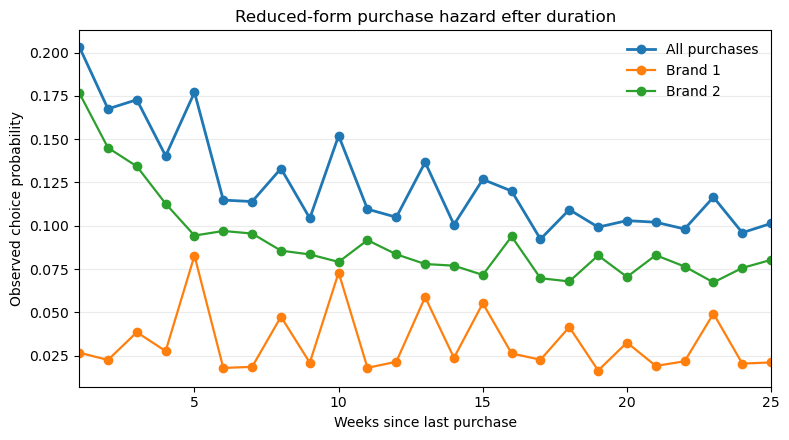

In [36]:
# Summarize observed choice rates by duration.
duration_summary = (
    panel_df.assign(
        purchase=(panel_df["Y"] > 0).astype(int),
        brand_1=(panel_df["Y"] == 1).astype(int),
        brand_2=(panel_df["Y"] == 2).astype(int),
    )
    .groupby("D")
    .agg(
        obs=("Y", "size"),
        purchase_rate=("purchase", "mean"),
        brand_1_rate=("brand_1", "mean"),
        brand_2_rate=("brand_2", "mean"),
    )
    .reset_index()
)


# Plot purchase rates by duration.
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(duration_summary["D"], duration_summary["purchase_rate"], marker="o", lw=2, label="All purchases")
ax.plot(duration_summary["D"], duration_summary["brand_1_rate"], marker="o", lw=1.6, label="Brand 1")
ax.plot(duration_summary["D"], duration_summary["brand_2_rate"], marker="o", lw=1.6, label="Brand 2")
ax.set_xlim(1, D_MAX)
ax.set_xlabel("Weeks since last purchase")
ax.set_ylabel("Observed choice probability")
ax.set_title(r"Reduced-form purchase hazard efter duration")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Inner Loop: Empirical VFI and CCPs


In [ ]:
# Solve the Bellman fixed point for one parameter vector.
def solve_vfi(
    alpha: np.ndarray,                    # brand intercepts
    gamma: np.ndarray,                    # price sensitivity
    beta_sc: np.ndarray,                  # switching-cost matrix
    beta_dep: np.ndarray,                 # depletion coefficients
    tol: float = VFI_TOL,                 # convergence tolerance
    max_iter: int = VFI_MAXITER,          # iteration limit
) -> np.ndarray:
    dur_idx  = np.arange(D_MAX + 1)                         # duration indices
    duration = dur_idx.astype(float)                         # duration values
    next_dur = np.minimum(dur_idx + 1, D_MAX)                # capped next duration

    # No-purchase utility term with alpha_1 normalized to zero.
    no_purch = alpha[:, None] - beta_dep[:, None] * duration[None, :]

    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))          # choice values
    V = np.zeros((J, D_MAX + 1, N_PROMO))                     # initial value function
    # Expected value function
    for _ in range(max_iter):
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX + 1, N_PROMO)  # continuation value

        # No purchase: advance duration while retaining the last brand.
        Q[..., 0] = no_purch[:, :, None] + DELTA * EV[:, next_dur, :]

        # Purchase brand j - Reset state to brand j at duration one.
        for j in range(J):
            Q[..., j + 1] = (
                alpha[j]
                - gamma * PRICE_BY_PROMO[:, j][None, None, :]
                - beta_sc[:, j][:, None, None]
                + DELTA * EV[j, 1, :][None, None, :]
            )
        # Max expected utility
        q_max = Q.max(axis=3)                                 
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))  
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new

    return V


# Convert value function into choice probabilities
def compute_ccps(
    V: np.ndarray,                        # solved value function
    alpha: np.ndarray,                    # brand intercepts
    gamma: np.ndarray,                    # price sensitivity
    beta_sc: np.ndarray,                  # switching-cost matrix
    beta_dep: np.ndarray,                 # depletion coefficients
) -> np.ndarray:
    # Return CCPs 
    dur_idx  = np.arange(D_MAX + 1) # duration indices
    duration = dur_idx.astype(float) # duration values
    next_dur = np.minimum(dur_idx + 1, D_MAX) # capped next duration

    no_purch = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T).reshape(J, D_MAX + 1, N_PROMO)
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))          # choice values
    Q[..., 0] = no_purch[:, :, None] + DELTA * EV[:, next_dur, :]
    for j in range(J):
        Q[..., j + 1] = (
            alpha[j]
            - gamma * PRICE_BY_PROMO[:, j][None, None, :]
            - beta_sc[:, j][:, None, None]
            + DELTA * EV[j, 1, :][None, None, :]
        )

    w = np.exp(Q - Q.max(axis=3, keepdims=True))             
    return w / w.sum(axis=3, keepdims=True)    


# Evaluate the log-likelihood 
def log_lik(counts: np.ndarray, P: np.ndarray) -> float:
    return float(np.sum(counts * np.log(np.maximum(P, 1e-300))))



VFI and CCP functions ready (alpha_1 = 0, alpha_2 relative to Brand 1).


## 7. Log-Likelihood and NFXP Parameters
**NFXP computation:** For each candidate parameter vector, the inner loop solves the Bellman equation and computes CCPs; the outer objective evaluates the negative empirical log-likelihood.

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# PARAMETER CONFIGURATION
# True  -> estimated freely
# False -> fixed at the PARAM_INIT value
# ─────────────────────────────────────────────────────────────────────────────
PARAM_FREE = {
    "alpha_1":  False,  # Brand 1 intercept normalization
    "alpha_2":  True,   # Brand 2 relative utility
    "gamma":    True,   # price sensitivity
    "beta_dep": True,   # depletion coefficient
    "beta_sc":  True,   # switching cost
}

# Initial values; used as fixed values when PARAM_FREE[p] is False.
PARAM_INIT = {
    "alpha_1":   0.00,   # normalized Brand 1 utility
    "alpha_2":   0.10,   # initial Brand 2 utility
    "gamma":     0.05,   # initial price sensitivity
    "beta_dep":  0.275,  # initial depletion coefficient
    "beta_sc":   0.25,   # initial switching cost
}

# Bounds for L-BFGS-B.
PARAM_BOUNDS = {
    "alpha_1":  (-10.0, 5.0),
    "alpha_2":  (-10.0, 5.0),
    "gamma":    (1e-4,  1.0),
    # Unrestricted duration effect: positive beta_dep increases purchase propensity.
    "beta_dep": (-5.0,  5.0),
    "beta_sc":  (0.0,   5.0),
}

# Grid points for sequential profile search.
PARAM_GRIDS = {
    "alpha_1":  np.linspace(-5.0, 1.0,  10),
    "alpha_2":  np.linspace(-1.0, 3.0,  10),
    "gamma":    np.linspace(0.01, 0.30, 10),
    "beta_dep": np.linspace(-1.00, 1.00, 11),
    "beta_sc":  np.linspace(0.0,  2.0,  10),
}

# ─────────────────────────────────────────────────────────────────────────────
ALL_PARAM_NAMES = ["alpha_1", "alpha_2", "gamma", "beta_dep", "beta_sc"]  # parameter order
FREE_PARAMS     = [p for p in ALL_PARAM_NAMES if PARAM_FREE[p]]                # estimated names
FIXED_PARAMS    = {p: PARAM_INIT[p] for p in ALL_PARAM_NAMES if not PARAM_FREE[p]}  # fixed values


# Combine optimized and fixed parameter values.
def full_param_vec(free_vals) -> list:
    """Combine free parameters with fixed PARAM_INIT values."""
    d = dict(FIXED_PARAMS)
    for name, val in zip(FREE_PARAMS, free_vals):
        d[name] = float(val)
    return [d[p] for p in ALL_PARAM_NAMES]


# Build the vector of brand utility intercepts.
def make_alpha(alpha_1: float, alpha_2: float) -> np.ndarray:
    return np.array([alpha_1, alpha_2])

# Apply a common depletion coefficient to both brands.
def make_beta_dep(beta_dep: float) -> np.ndarray:
    return np.array([beta_dep, beta_dep])

# Build a symmetric switching-cost matrix.
def make_beta_sc(beta_sc: float) -> np.ndarray:
    """Return the symmetric switching-cost matrix."""
    return np.array([[0.0,     beta_sc],
                     [beta_sc, 0.0    ]])

# Return the negative NFXP log-likelihood.
def neg_ll(free_vals) -> float:
    """Return negative log-likelihood for free parameters only."""
    alpha_1, alpha_2, gamma, beta_dep, beta_sc = full_param_vec(free_vals)
    alpha        = make_alpha(alpha_1, alpha_2)               # brand utilities
    beta_dep_vec = make_beta_dep(beta_dep)                    # depletion vector
    beta_sc_mat  = make_beta_sc(beta_sc)                      # switching matrix
    V = solve_vfi(alpha, gamma, beta_sc_mat, beta_dep_vec)    # solved values
    P = compute_ccps(V, alpha, gamma, beta_sc_mat, beta_dep_vec)  # fitted CCPs
    return -log_lik(OBS_COUNTS, P)


print(f"Free parameters  ({len(FREE_PARAMS)}): {FREE_PARAMS}")
print(f"Fixed parameters ({len(FIXED_PARAMS)}): {FIXED_PARAMS}")
print("\nOverview:")
for p in ALL_PARAM_NAMES:
    if PARAM_FREE[p]:
        print(f"  {p:<12}  True   (init = {PARAM_INIT[p]})")
    else:
        print(f"  {p:<12}  False  (fixed = {PARAM_INIT[p]})")

Free parameters  (4): ['alpha_2', 'gamma', 'beta_dep', 'beta_sc']
Fixed parameters (1): {'alpha_1': 0.0}

Overview:
  alpha_1       False  (fixed = 0.0)
  alpha_2       True   (init = 0.1)
  gamma         True   (init = 0.05)
  beta_dep      True   (init = 0.275)
  beta_sc       True   (init = 0.25)


## 8. Grid Initialization: Sequential One-Dimensional Searches

For each free parameter, the notebook evaluates a grid while holding the other parameters at the best values found so far. Two sequential rounds provide a stable starting point for the continuous NFXP outer optimization; this is initialization rather than the final estimator.

In [25]:
# Sequential one-dimensional profiles over free parameters (two rounds).
best_free = [PARAM_INIT[p] for p in FREE_PARAMS]  # current grid solution

t0 = time.perf_counter()  # grid-search timer
for round_idx in range(2):
    for fi, pname in enumerate(FREE_PARAMS):
        grid = PARAM_GRIDS[pname]  # candidate parameter values
        lls  = []                  # log-likelihood values
        for val in grid:
            trial     = list(best_free)
            trial[fi] = val
            lls.append(-neg_ll(trial))
        best_idx      = int(np.nanargmax(lls))
        best_free[fi] = float(grid[best_idx])
        print(f"  Round {round_idx+1}  [{pname:<12}]  best={best_free[fi]:.4f}  LL={lls[best_idx]:.2f}")

full_best = full_param_vec(best_free)
print(f"\nBest grid point:")
for name, val in zip(ALL_PARAM_NAMES, full_best):
    tag = "  [fixed]" if name in FIXED_PARAMS else ""
    print(f"  {name:<15} = {val:.4f}{tag}")
print(f"  LL = {-neg_ll(best_free):.2f}")
print(f"Grid search took {time.perf_counter() - t0:.1f}s")

# ── Build 2D contour grid when alpha_2 and gamma are both free ──
if "alpha_2" in FREE_PARAMS and "gamma" in FREE_PARAMS:
    GRID_A2  = PARAM_GRIDS["alpha_2"]
    GRID_GAM = PARAM_GRIDS["gamma"]
    fi_a2    = FREE_PARAMS.index("alpha_2")
    fi_gam   = FREE_PARAMS.index("gamma")
    ll_grid2d = np.full((len(GRID_A2), len(GRID_GAM)), np.nan)
    base = list(best_free)
    for i, a2 in enumerate(GRID_A2):
        for k, gam in enumerate(GRID_GAM):
            trial          = list(base)
            trial[fi_a2]   = a2
            trial[fi_gam]  = gam
            ll_grid2d[i, k] = -neg_ll(trial)
    print(f"\nContour grid (alpha_2 x gamma) ready; max LL = {np.nanmax(ll_grid2d):.2f}")
else:
    ll_grid2d = None
    GRID_A2   = None
    GRID_GAM  = None
    print("\nContour plot skipped (alpha_2 and/or gamma is fixed).")

  Round 1  [alpha_2     ]  best=0.3333  LL=-3282362.67
  Round 1  [gamma       ]  best=0.3000  LL=-2062761.79
  Round 1  [beta_dep    ]  best=0.0000  LL=-1066874.39
  Round 1  [beta_sc     ]  best=0.0000  LL=-1058384.81
  Round 2  [alpha_2     ]  best=-0.1111  LL=-986995.28
  Round 2  [gamma       ]  best=0.1711  LL=-810259.80
  Round 2  [beta_dep    ]  best=0.0000  LL=-810259.80
  Round 2  [beta_sc     ]  best=0.6667  LL=-791244.30

Best grid point:
  alpha_1         = 0.0000  [fixed]
  alpha_2         = -0.1111
  gamma           = 0.1711
  beta_dep        = 0.0000
  beta_sc         = 0.6667
  LL = -791244.30
Grid search took 1.6s

Contour grid (alpha_2 x gamma) ready; max LL = -791244.30


## 9. NFXP Outer Optimization with `minimize` (L-BFGS-B)

Starting from the grid-search solution, bounded L-BFGS-B refines the maximum-likelihood estimate. Each outer evaluation entails a new VFI and CCP computation, which is the nested fixed point structure.

Converged: True  |  Iterations: 20  |  Time: 2.9s

  Parameter         Estimate Std. error        z      p-value  
  --------------------------------------------------------------
  alpha_1           0.000000          —        —            —  [fixed]
  alpha_2          -0.044710   0.000588 -76.0657 0.0000e+00  ***
  gamma             0.145569   0.000253 574.6971 0.0000e+00  ***
  beta_dep         -0.004998   0.000071 -70.2755 0.0000e+00  ***
  beta_sc           0.777214   0.004854 160.1019 0.0000e+00  ***
  --------------------------------------------------------------
  Log-lik = -778575.93  (N_obs = 1,697,631)
  Significance levels: *** p<0.01  ** p<0.05  * p<0.1


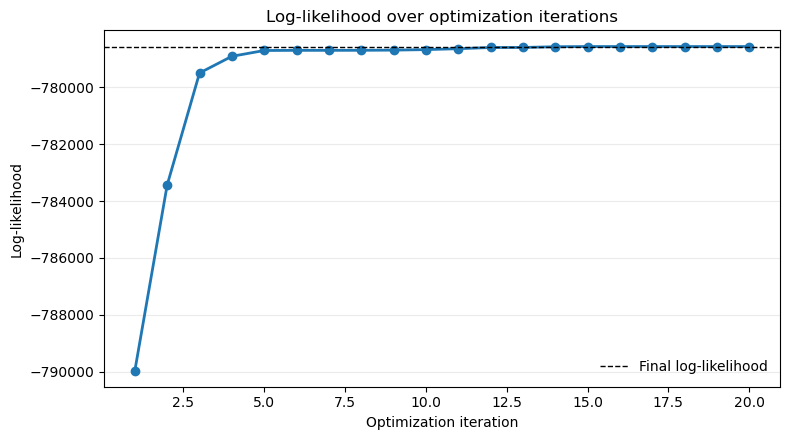

In [26]:
x0     = np.array(best_free)                     # optimizer start
bounds = [PARAM_BOUNDS[p] for p in FREE_PARAMS]  # optimizer bounds

ll_iter_trace = []  # outer-loop likelihood path

# Record the log-likelihood after each optimizer iteration.
def opt_callback(xk):
    ll_iter_trace.append(-neg_ll(xk))

t0 = time.perf_counter()
res = minimize(
    neg_ll,
    x0,
    method="L-BFGS-B",
    bounds=bounds,
    callback=opt_callback,
    options={"ftol": 1e-10, "gtol": 1e-7, "maxiter": 500},
)
elapsed = time.perf_counter() - t0

if not res.success:
    print(f"WARNING: Optimizer did not report convergence: {res.message}")

# Extract the full parameter vector.
full_hat = full_param_vec(res.x)  # complete estimate vector
ALPHA_1_HAT, ALPHA_2_HAT, GAMMA_HAT, BETA_DEP_HAT, BETA_SC_HAT = full_hat
LL_HAT = -float(res.fun)  # maximized log-likelihood

# ── Detect boundary estimates ──────────────────────────────────────────────────
BOUND_TOL = 1e-6             # bound-detection tolerance
n_free    = len(FREE_PARAMS) # number of free parameters
at_bound  = np.array([
    abs(res.x[i] - bounds[i][0]) < BOUND_TOL or
    abs(res.x[i] - bounds[i][1]) < BOUND_TOL
    for i in range(n_free)
])
interior  = [i for i in range(n_free) if not at_bound[i]]

if any(at_bound):
    bound_names = [FREE_PARAMS[i] for i in range(n_free) if at_bound[i]]
    print(f"INFO: {bound_names} is at a bound; standard errors omitted")

# ── Numerical Hessian over interior parameters only ───────────────────────────
h_step  = 1e-4                    # finite-difference step
SE_free = np.full(n_free, np.nan) # standard-error storage

if interior and np.all(np.isfinite(res.x)):
    n_int    = len(interior)
    hess_int = np.full((n_int, n_int), np.nan)
    for ii, pi in enumerate(interior):
        for jj, pj in enumerate(interior):
            ep = np.zeros(n_free); ep[pi] = h_step
            eq = np.zeros(n_free); eq[pj] = h_step
            f_pp = neg_ll(res.x + ep + eq)
            f_pm = neg_ll(res.x + ep - eq)
            f_mp = neg_ll(res.x - ep + eq)
            f_mm = neg_ll(res.x - ep - eq)
            if np.all(np.isfinite([f_pp, f_pm, f_mp, f_mm])):
                hess_int[ii, jj] = (f_pp - f_pm - f_mp + f_mm) / (4 * h_step**2)

    if np.all(np.isfinite(hess_int)):
        try:
            cov_int  = np.linalg.inv(hess_int)
            diag_int = np.diag(cov_int)
            if not np.all(np.isfinite(diag_int)) or np.any(diag_int < 0):
                print("INFO: Hessian is not positive definite; using pseudo-inverse")
                cov_int  = np.linalg.pinv(hess_int)
                diag_int = np.diag(cov_int)
            for ii, i in enumerate(interior):
                SE_free[i] = np.sqrt(max(float(diag_int[ii]), 0.0))
        except np.linalg.LinAlgError:
            print("WARNING: Hessian is singular; standard errors unavailable")
    else:
        print("WARNING: Hessian contains NaN; standard errors unavailable")

SE_dict = {p: np.nan for p in ALL_PARAM_NAMES}
for i, name in enumerate(FREE_PARAMS):
    SE_dict[name] = float(SE_free[i])

SE_ALPHA_1  = SE_dict["alpha_1"]
SE_ALPHA_2  = SE_dict["alpha_2"]
SE_GAMMA    = SE_dict["gamma"]
SE_BETA_DEP = SE_dict["beta_dep"]
SE_BETA_SC  = SE_dict["beta_sc"]

# ── Results summary ────────────────────────────────────────────────────────────
# Compute a z-statistic when its standard error is valid.
def zstat(est, se): return est / se if np.isfinite(se) and se > 0 else np.nan
# Compute a two-sided normal p-value.
def pval(z):        return float(2 * norm.sf(abs(z))) if np.isfinite(z) else np.nan
# Convert a p-value to a significance marker.
def stars(p):
    if not np.isfinite(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""

free_idx = {name: i for i, name in enumerate(FREE_PARAMS)}
est_map  = dict(zip(ALL_PARAM_NAMES,
                    [ALPHA_1_HAT, ALPHA_2_HAT, GAMMA_HAT, BETA_DEP_HAT, BETA_SC_HAT]))

print(f"Converged: {res.success}  |  Iterations: {res.nit}  |  Time: {elapsed:.1f}s")
print(f"\n{'='*67}")
print(f"  {'Parameter':<15} {'Estimate':>10} {'Std. error':>10} {'z':>8} {'p-value':>12}  ")
print(f"  {'-'*62}")
for name in ALL_PARAM_NAMES:
    est = est_map[name]
    if name in FIXED_PARAMS:
        print(f"  {name:<15} {est:>10.6f} {'—':>10} {'—':>8} {'—':>12}  [fixed]")
    elif at_bound[free_idx[name]]:
        print(f"  {name:<15} {est:>10.6f} {'—':>10} {'—':>8} {'—':>12}  [bound]")
    else:
        se = SE_dict[name]
        z  = zstat(est, se)
        p  = pval(z)
        print(f"  {name:<15} {est:>10.6f} {se:>10.6f} {z:>8.4f} {p:>10.4e}  {stars(p)}")
print(f"  {'-'*62}")
print(f"{'='*67}")
print(f"  Log-lik = {LL_HAT:.2f}  (N_obs = {N_OBS:,})")
print("  Significance levels: *** p<0.01  ** p<0.05  * p<0.1")

# ── Log-likelihood trace over outer optimizer iterations ───────────────────
if ll_iter_trace:
    ll_iter_trace = np.array(ll_iter_trace, dtype=float)
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(
        np.arange(1, len(ll_iter_trace) + 1),
        ll_iter_trace,
        marker="o",
        lw=2,
        color="#1F77B4",
    )
    ax.axhline(LL_HAT, color="black", lw=1, ls="--", label="Final log-likelihood")
    ax.set_xlabel("Optimization iteration")
    ax.set_ylabel("Log-likelihood")
    ax.set_title("Log-likelihood over optimization iterations")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig("nfxp_empirical_ll_optimization_trace.pdf", bbox_inches="tight")
    plt.show()
else:
    print("No optimizer iterations recorded in ll_iter_trace.")


## 9b. Likelihood Slices for Free Parameters

One parameter is varied at a time around the estimate while all other parameters remain fixed at the MLE. These plots are a quick local identification diagnostic, not full profile likelihoods with reoptimization.

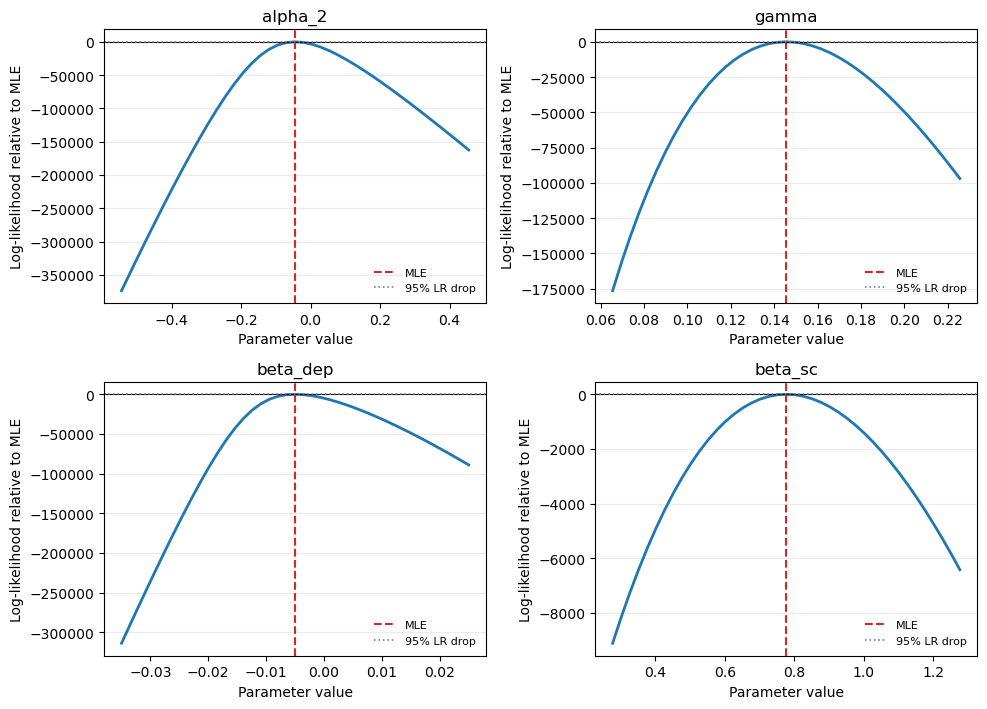

Likelihood slices saved to nfxp_empirical_likelihood_slices.pdf
Fixed parameters without a likelihood slice: ['alpha_1']


In [27]:
# ── 1D likelihood slices around the MLE ─────────────────────────────────────
SLICE_POINTS = 41  # evaluations per likelihood slice
SLICE_WINDOWS = {
    "alpha_1": 0.50,
    "alpha_2": 0.50,
    "gamma": 0.08,
    "beta_dep": 0.03,
    "beta_sc": 0.50,
}

slice_results = {}  # slice tables by parameter
for i, pname in enumerate(FREE_PARAMS):
    est = float(res.x[i])
    lo, hi = PARAM_BOUNDS[pname]
    width = SLICE_WINDOWS.get(pname, 0.25 * max(abs(est), 1.0))
    grid_lo = max(lo, est - width)
    grid_hi = min(hi, est + width)

    if np.isclose(grid_lo, grid_hi):
        print(f"Skipping {pname}: grid is too narrow near its bound")
        continue

    grid = np.linspace(grid_lo, grid_hi, SLICE_POINTS)
    if not np.any(np.isclose(grid, est)):
        grid = np.sort(np.r_[grid, est])

    ll_vals = np.empty_like(grid, dtype=float)
    for k, val in enumerate(grid):
        trial = np.array(res.x, dtype=float)
        trial[i] = val
        ll_vals[k] = -neg_ll(trial)

    slice_results[pname] = pd.DataFrame({
        "param_value": grid,
        "log_likelihood": ll_vals,
        "delta_log_likelihood": ll_vals - LL_HAT,
    })

if slice_results:
    n_plots = len(slice_results)
    n_cols = 2
    n_rows = int(np.ceil(n_plots / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 3.6 * n_rows), squeeze=False)
    axes_flat = axes.ravel()
    lr95_drop = -0.5 * chi2.ppf(0.95, df=1)  # 95 percent LR cutoff

    for ax, (pname, frame) in zip(axes_flat, slice_results.items()):
        est = float(res.x[FREE_PARAMS.index(pname)])
        ax.plot(frame["param_value"], frame["delta_log_likelihood"], lw=2, color="#1F77B4")
        ax.axvline(est, color="#D62728", ls="--", lw=1.5, label="MLE")
        ax.axhline(0.0, color="black", lw=0.8)
        ax.axhline(lr95_drop, color="gray", ls=":", lw=1.2, label="95% LR drop")
        ax.set_title(pname)
        ax.set_xlabel("Parameter value")
        ax.set_ylabel("Log-likelihood relative to MLE")
        ax.grid(axis="y", alpha=0.25)
        ax.legend(frameon=False, fontsize=8)

    for ax in axes_flat[n_plots:]:
        ax.axis("off")

    plt.tight_layout()
    plt.savefig("nfxp_empirical_likelihood_slices.pdf", bbox_inches="tight")
    plt.show()

    print("Likelihood slices saved to nfxp_empirical_likelihood_slices.pdf")
    if FIXED_PARAMS:
        print(f"Fixed parameters without a likelihood slice: {list(FIXED_PARAMS.keys())}")


## 10. Estimates and Model Fit

The final output reports likelihood behavior and compares observed choice shares with predictions from the fitted dynamic model, including fit over calendar time and duration since the last purchase.

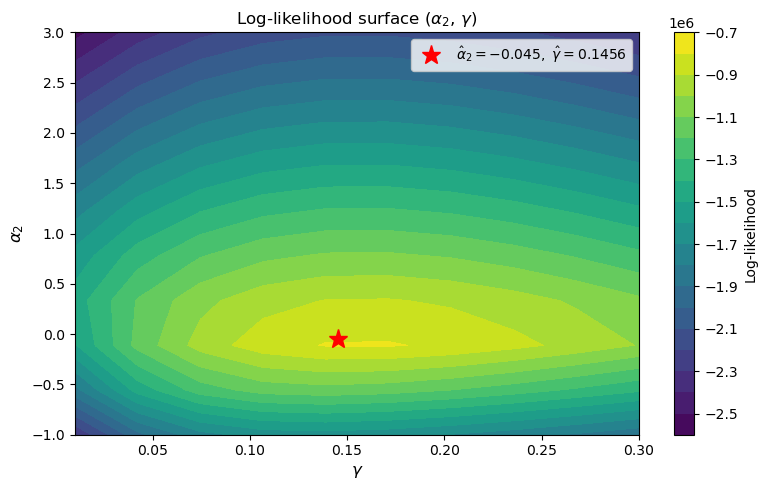


Observed versus predicted choice probabilities:
     Choice  Observed share  Predicted share  Difference
No purchase          0.8479           0.8571      0.0092
    Brand 1          0.0337           0.0297     -0.0040
    Brand 2          0.1184           0.1132     -0.0053


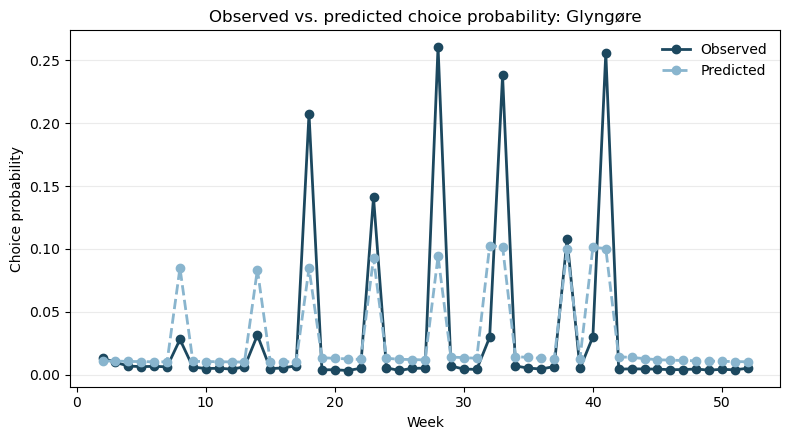

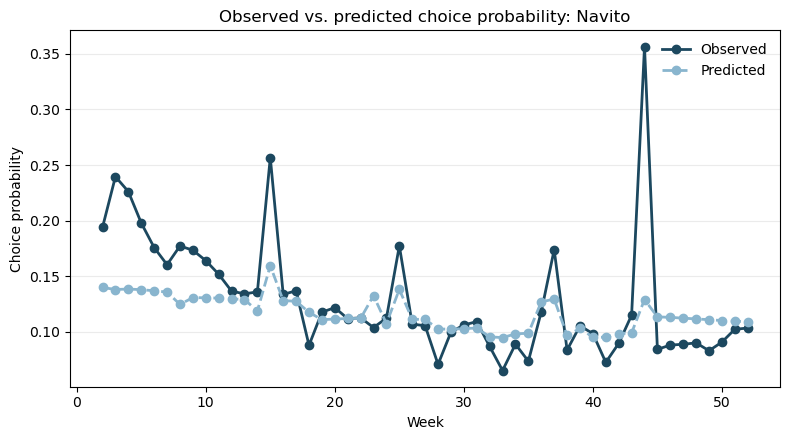

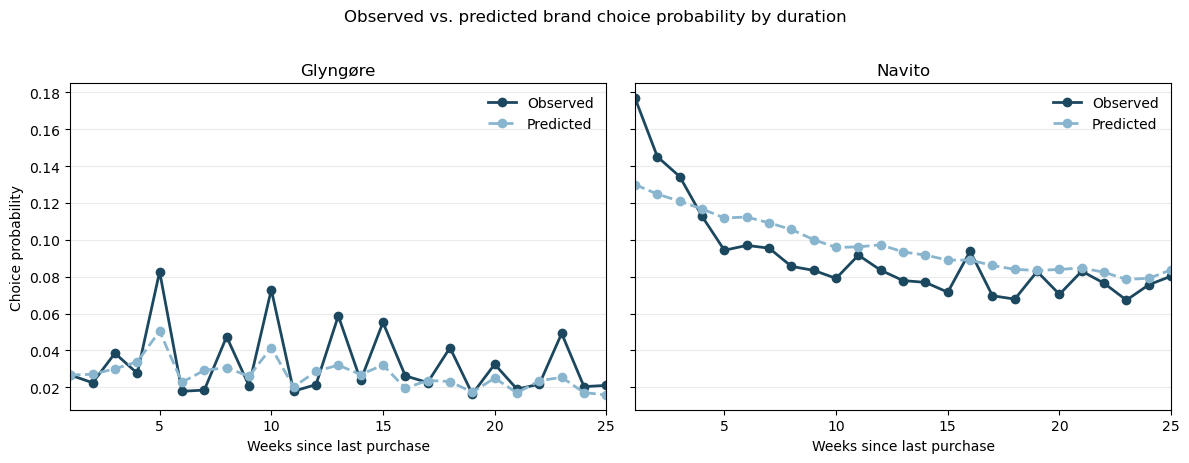

In [28]:
# ── Contour plot of the likelihood surface ─────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.contourf(GRID_GAM, GRID_A2, ll_grid2d, levels=20, cmap="viridis")  # likelihood contours
plt.colorbar(cf, ax=ax, label="Log-likelihood")
ax.plot(GAMMA_HAT, ALPHA_2_HAT, "r*", ms=14,
        label=rf"$\hat{{\alpha}}_2={ALPHA_2_HAT:.3f},\ \hat{{\gamma}}={GAMMA_HAT:.4f}$")
ax.set_xlabel(r"$\gamma$", fontsize=12)
ax.set_ylabel(r"$\alpha_2$", fontsize=12)
ax.set_title(r"Log-likelihood surface $(\alpha_2,\,\gamma)$", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("nfxp_empirical_joint.pdf", bbox_inches="tight")
plt.show()

# ── Fitted versus observed choice probabilities ─────────────────────────────
alpha_hat    = make_alpha(ALPHA_1_HAT, ALPHA_2_HAT)        # fitted utilities
beta_dep_hat = make_beta_dep(BETA_DEP_HAT)                 # fitted depletion
beta_sc_hat  = make_beta_sc(BETA_SC_HAT)                   # fitted switching cost
V_hat = solve_vfi(alpha_hat, GAMMA_HAT, beta_sc_hat, beta_dep_hat)  # fitted values
P_hat = compute_ccps(V_hat, alpha_hat, GAMMA_HAT, beta_sc_hat, beta_dep_hat)  # fitted CCPs

state_counts = OBS_COUNTS.sum(axis=3)  # observations by state
obs_shares   = OBS_COUNTS.sum(axis=(0, 1, 2)) / N_OBS  # observed choice shares
pred_shares  = (state_counts[..., None] * P_hat).sum(axis=(0, 1, 2)) / N_OBS  # fitted shares

fit_table = pd.DataFrame({
    "Choice":             ["No purchase", "Brand 1", "Brand 2"],
    "Observed share":     obs_shares,
    "Predicted share":    pred_shares,
    "Difference":         pred_shares - obs_shares,
})
print("\nObserved versus predicted choice probabilities:")
print(fit_table.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# ── Brand-specific observed versus predicted over time ──────────────────────
panel_df["pred_glyngore_prob"] = P_hat[
    panel_df["L"].to_numpy(dtype=int) - 1,
    panel_df["D"].to_numpy(dtype=int),
    panel_df["E_IDX"].to_numpy(dtype=int),
    1,
]
panel_df["pred_navito_prob"] = P_hat[
    panel_df["L"].to_numpy(dtype=int) - 1,
    panel_df["D"].to_numpy(dtype=int),
    panel_df["E_IDX"].to_numpy(dtype=int),
    2,
]

panel_df["actual_glyngore"] = (panel_df["Y"] == 1).astype(int)
panel_df["actual_navito"] = (panel_df["Y"] == 2).astype(int)

weekly_brand_fit = (
    panel_df
    .groupby("week_num")
    .agg(
        actual_glyngore_prob=("actual_glyngore", "mean"),
        predicted_glyngore_prob=("pred_glyngore_prob", "mean"),
        actual_navito_prob=("actual_navito", "mean"),
        predicted_navito_prob=("pred_navito_prob", "mean"),
        obs=("Y", "size"),
    )
    .reset_index()
)

COLOR_OBS = "#1c485f"   # observed-series color
COLOR_PRED = "#89b5ce"  # predicted-series color

# Glyngøre
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["actual_glyngore_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["predicted_glyngore_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
ax.set_xlabel("Week")
ax.set_ylabel("Choice probability")
ax.set_title("Observed vs. predicted choice probability: Glyngøre")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("nfxp_empirical_glyngore_fit_over_time.pdf", bbox_inches="tight")
plt.show()

# Navito
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["actual_navito_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
ax.plot(
    weekly_brand_fit["week_num"],
    weekly_brand_fit["predicted_navito_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
ax.set_xlabel("Week")
ax.set_ylabel("Choice probability")
ax.set_title("Observed vs. predicted choice probability: Navito")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("nfxp_empirical_navito_fit_over_time.pdf", bbox_inches="tight")
plt.show()


# ── Brand-specific observed vs. predicted by duration ──────────────────────
duration_brand_fit = (
    panel_df
    .groupby("D")
    .agg(
        actual_glyngore_prob=("actual_glyngore", "mean"),
        predicted_glyngore_prob=("pred_glyngore_prob", "mean"),
        actual_navito_prob=("actual_navito", "mean"),
        predicted_navito_prob=("pred_navito_prob", "mean"),
        obs=("Y", "size"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

axes[0].plot(
    duration_brand_fit["D"],
    duration_brand_fit["actual_glyngore_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
axes[0].plot(
    duration_brand_fit["D"],
    duration_brand_fit["predicted_glyngore_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
axes[0].set_title("Glyngøre")
axes[0].set_xlabel("Weeks since last purchase")
axes[0].set_ylabel("Choice probability")
axes[0].set_xlim(1, D_MAX)
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(frameon=False)

axes[1].plot(
    duration_brand_fit["D"],
    duration_brand_fit["actual_navito_prob"],
    marker="o",
    lw=2,
    color=COLOR_OBS,
    label="Observed",
)
axes[1].plot(
    duration_brand_fit["D"],
    duration_brand_fit["predicted_navito_prob"],
    marker="o",
    lw=2,
    ls="--",
    color=COLOR_PRED,
    label="Predicted",
)
axes[1].set_title("Navito")
axes[1].set_xlabel("Weeks since last purchase")
axes[1].set_xlim(1, D_MAX)
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(frameon=False)

fig.suptitle("Observed vs. predicted brand choice probability by duration", y=1.02)
plt.tight_layout()
plt.savefig("nfxp_empirical_brand_fit_by_duration.pdf", bbox_inches="tight")
plt.show()


## 11. Counterfactuals og elasticiteter

Alle counterfactuals re-solvér VFI med ændrede prisantagelser og beregner den tilhørende **stationære fordeling** via power iteration.

- **Short-run elasticitet**: umiddelbar reaktion, tilstand $(\ell, d, e)$ holdes fast — analytisk formel fra logit-CCPs
- **Long-run elasticitet**: reaktion efter fuld re-sortering til ny stationær fordeling — numerisk via prisperturbation


Counterfactual: Ingen promotions
  Brand 1 pris: 24.950 kr. (altid RRP)   Brand 2 pris: 11.950 kr. (altid RRP)

  Valg                     Baseline  Ingen promo    Forskel   %-ændring
  --------------------------------------------------------------------
  Ingen køb                  0.8635       0.8767    +0.0132       +1.5%
  Brand 1 (Glyngøre)         0.0275       0.0089    -0.0186      -67.8%
  Brand 2 (Navito)           0.1091       0.1145    +0.0054       +5.0%


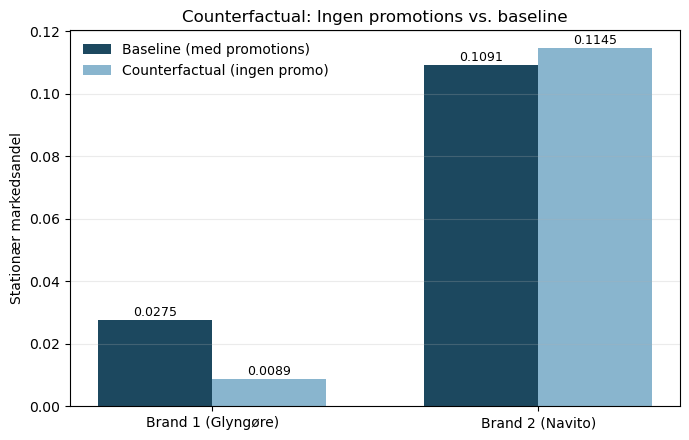

In [29]:
# ── Stationær fordeling via power iteration ───────────────────────────────────
def compute_stationary(P, trans, n_iter=5_000, tol=1e-10):
    """Stationær fordeling over (J, D_MAX+1, N_PROMO) via power iteration."""
    mu = np.full((J, D_MAX + 1, N_PROMO), 1.0 / (J * (D_MAX + 1) * N_PROMO))
    for _ in range(n_iter):
        mu_new = np.zeros_like(mu)
        # Ingen køb: (l, d, e) → (l, min(d+1, D_MAX), e')
        flow0 = mu * P[..., 0]
        shifted = np.zeros_like(flow0)
        shifted[:, 1:,    :] = flow0[:, :-1, :]
        shifted[:, D_MAX, :] += flow0[:, D_MAX, :]
        mu_new += shifted @ trans
        # Køb brand j: (l, d, e) → (j, 1, e')
        for j in range(J):
            mu_new[j, 1, :] += (mu * P[..., j + 1]).sum(axis=(0, 1)) @ trans
        mu_new /= mu_new.sum()
        if np.max(np.abs(mu_new - mu)) < tol:
            return mu_new
        mu = mu_new
    return mu


def vfi_with_prices(price_mat, trans_mat):
    """Re-solvér VFI og CCP med alternative priser og overgangsmatrix."""
    global PRICE_BY_PROMO, PROMO_TRANS
    _p, _t         = PRICE_BY_PROMO.copy(), PROMO_TRANS.copy()
    PRICE_BY_PROMO = price_mat
    PROMO_TRANS    = trans_mat
    alpha   = make_alpha(ALPHA_1_HAT, ALPHA_2_HAT)
    bdep    = make_beta_dep(BETA_DEP_HAT)
    bsc     = make_beta_sc(BETA_SC_HAT)
    V = solve_vfi(alpha, GAMMA_HAT, bsc, bdep)
    P = compute_ccps(V, alpha, GAMMA_HAT, bsc, bdep)
    PRICE_BY_PROMO, PROMO_TRANS = _p, _t
    return P


# ── Baseline stationær fordeling ──────────────────────────────────────────────
mu_base     = compute_stationary(P_hat, PROMO_TRANS)
shares_base = np.array([(mu_base * P_hat[..., j]).sum() for j in range(N_CHOICES)])


# ── Counterfactual: ingen promotions ──────────────────────────────────────────
RRP_B1   = price_promo_df["RRP_Brand_1"].median()
RRP_B2   = price_promo_df["RRP_Brand_2"].median()
PRICE_CF = np.tile(np.array([RRP_B1, RRP_B2]), (N_PROMO, 1))  # alle tilstande → RRP
TRANS_CF = np.zeros((N_PROMO, N_PROMO)); TRANS_CF[:, 0] = 1.0  # altid e=(0,0)

P_cf      = vfi_with_prices(PRICE_CF, TRANS_CF)
mu_cf     = compute_stationary(P_cf, TRANS_CF)
shares_cf = np.array([(mu_cf * P_cf[..., j]).sum() for j in range(N_CHOICES)])


# ── Tabel ─────────────────────────────────────────────────────────────────────
labels = ["Ingen køb", "Brand 1 (Glyngøre)", "Brand 2 (Navito)"]
print("Counterfactual: Ingen promotions")
print(f"  Brand 1 pris: {RRP_B1:.3f} kr. (altid RRP)   Brand 2 pris: {RRP_B2:.3f} kr. (altid RRP)")
print(f"\n  {'Valg':<22} {'Baseline':>10} {'Ingen promo':>12} {'Forskel':>10} {'%-ændring':>11}")
print("  " + "-" * 68)
for j, lbl in enumerate(labels):
    diff = shares_cf[j] - shares_base[j]
    pct  = diff / shares_base[j] * 100 if shares_base[j] > 0 else float("nan")
    print(f"  {lbl:<22} {shares_base[j]:>10.4f} {shares_cf[j]:>12.4f} {diff:>+10.4f} {pct:>+10.1f}%")


# ── Barplot ───────────────────────────────────────────────────────────────────
x, w = np.arange(J), 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - w/2, shares_base[1:], w, label="Baseline (med promotions)",   color="#1c485f")
ax.bar(x + w/2, shares_cf[1:],   w, label="Counterfactual (ingen promo)", color="#89b5ce")
for i, (b, c) in enumerate(zip(shares_base[1:], shares_cf[1:])):
    ax.text(i - w/2, b + 0.0003, f"{b:.4f}", ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, c + 0.0003, f"{c:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Brand 1 (Glyngøre)", "Brand 2 (Navito)"])
ax.set_ylabel("Stationær markedsandel")
ax.set_title("Counterfactual: Ingen promotions vs. baseline")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("nfxp_empirical_counterfactual_no_promo.pdf", bbox_inches="tight")
plt.show()


Short-run og long-run priselasticiteter
Fortolkning: ε[k, j] = %-ændring i brand k's andel ved 1%-stigning i brand j's pris

Short-run elasticiteter:
                           Pris Brand 1   Pris Brand 2
  ----------------------------------------------------
  Brand 1 (Glyngøre)            -3.1410         0.1852
  Brand 2 (Navito)               0.0595        -1.5208

Long-run elasticiteter (h=1% prisperturbation):
                           Pris Brand 1   Pris Brand 2
  ----------------------------------------------------
  Brand 1 (Glyngøre)            -2.7825         0.8539
  Brand 2 (Navito)               0.3667        -2.4933

Forskel (LR - SR):
                           Pris Brand 1   Pris Brand 2
  ----------------------------------------------------
  Brand 1 (Glyngøre)            +0.3585        +0.6687
  Brand 2 (Navito)              +0.3072        -0.9725


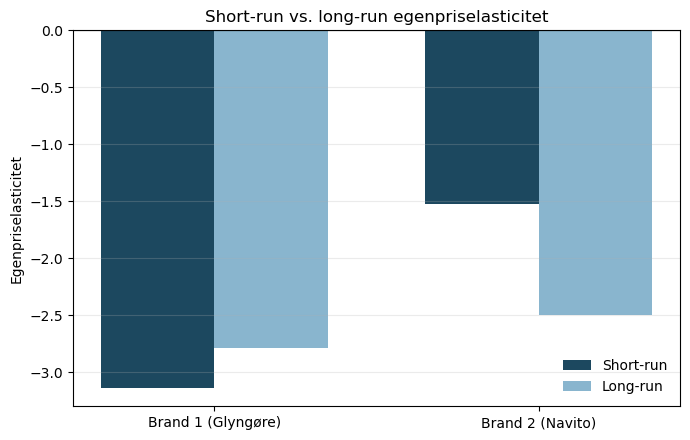

In [30]:
# ── Short-run elasticitet ─────────────────────────────────────────────────────
# Analytisk formel fra logit: ε_jj^SR(l,d,e) = -γ · p_j(e) · (1 - P_j(l,d,e))
# Kryds:                       ε_kj^SR(l,d,e) = +γ · p_j(e) · P_j(l,d,e)
# Vægtes med stationær fordeling mu_base

SR_elast = np.full((J, J), np.nan)   # SR_elast[k, j] = effekt af p_j på andel af brand k
for j in range(J):
    price_j = PRICE_BY_PROMO[:, j]                        # (N_PROMO,)
    P_j     = P_hat[..., j + 1]                           # (J, D_MAX+1, N_PROMO)
    for k in range(J):
        P_k = P_hat[..., k + 1]
        if k == j:
            eps = -GAMMA_HAT * price_j[None, None, :] * (1 - P_j)
        else:
            eps =  GAMMA_HAT * price_j[None, None, :] * P_j
        # Vægtet gennemsnit over stationær fordeling, betinget på at være i købs-tilstand
        SR_elast[k, j] = (mu_base * eps).sum() / mu_base.sum()


# ── Long-run elasticitet ──────────────────────────────────────────────────────
# Numerisk: forøg prisen på brand j med h=1%, re-solvér VFI, re-beregn stationær fordeling
h = 0.01
LR_elast = np.full((J, J), np.nan)   # LR_elast[k, j] = effekt af p_j på andel af brand k

for j in range(J):
    # Perturb pris på brand j
    PRICE_PERT = PRICE_BY_PROMO.copy()
    PRICE_PERT[:, j] *= (1 + h)

    P_pert    = vfi_with_prices(PRICE_PERT, PROMO_TRANS)
    mu_pert   = compute_stationary(P_pert, PROMO_TRANS)

    for k in range(J):
        share_base_k = (mu_base * P_hat[..., k + 1]).sum()
        share_pert_k = (mu_pert * P_pert[..., k + 1]).sum()
        LR_elast[k, j] = (share_pert_k - share_base_k) / share_base_k / h


# ── Resultattabel ─────────────────────────────────────────────────────────────
brand_names = ["Brand 1 (Glyngøre)", "Brand 2 (Navito)"]
print("Short-run og long-run priselasticiteter")
print("Fortolkning: ε[k, j] = %-ændring i brand k's andel ved 1%-stigning i brand j's pris")

print(f"\nShort-run elasticiteter:")
print(f"  {'':22} {'Pris Brand 1':>14} {'Pris Brand 2':>14}")
print("  " + "-" * 52)
for k in range(J):
    row = "  " + f"{brand_names[k]:<22}"
    for j in range(J):
        row += f" {SR_elast[k, j]:>14.4f}"
    print(row)

print(f"\nLong-run elasticiteter (h={h:.0%} prisperturbation):")
print(f"  {'':22} {'Pris Brand 1':>14} {'Pris Brand 2':>14}")
print("  " + "-" * 52)
for k in range(J):
    row = "  " + f"{brand_names[k]:<22}"
    for j in range(J):
        row += f" {LR_elast[k, j]:>14.4f}"
    print(row)

print(f"\nForskel (LR - SR):")
print(f"  {'':22} {'Pris Brand 1':>14} {'Pris Brand 2':>14}")
print("  " + "-" * 52)
for k in range(J):
    row = "  " + f"{brand_names[k]:<22}"
    for j in range(J):
        row += f" {LR_elast[k,j] - SR_elast[k,j]:>+14.4f}"
    print(row)


# ── Barplot: SR vs LR egenpriselasticitet ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4.5))
x, w = np.arange(J), 0.35
ax.bar(x - w/2, [SR_elast[j, j] for j in range(J)], w,
       label="Short-run", color="#1c485f")
ax.bar(x + w/2, [LR_elast[j, j] for j in range(J)], w,
       label="Long-run",  color="#89b5ce")
ax.axhline(0, color="black", lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(brand_names)
ax.set_ylabel("Egenpriselasticitet")
ax.set_title("Short-run vs. long-run egenpriselasticitet")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig("nfxp_empirical_elasticities.pdf", bbox_inches="tight")
plt.show()


## 12. Forward-looking vs. myopiske forbrugere

Sammenligner stationære brand-andele under to adfærdsantagelser:

- **Forward-looking** ($\\delta = 0.95$): forbrugeren internaliserer fremtidige switching costs og deprecieringseffekter — den estimerede model
- **Myopisk** ($\\delta = 0$): forbrugeren maksimerer kun periodens nytte og ignorerer fremtiden

For myopiske forbrugere reduceres choice-probabilities til **statisk logit** — ingen continuation value:
$$Q_0^{myo}(\\ell,d,e) = \\alpha_\\ell - \\beta^{dep}\\cdot d, \\qquad Q_j^{myo}(\\ell,d,e) = \\alpha_j - \\gamma\\cdot p_j(e) - \\beta^{sc}_{\\ell j}$$


Forward-looking (delta=0.95) vs. myopisk (delta=0)

  Valg                    Forward-looking    Myopisk    Forskel   %-ændring
  ------------------------------------------------------------------------
  Ingen køb                        0.8635     0.8421    -0.0214       -2.5%
  Brand 1 (Glyngøre)               0.0275     0.0329    +0.0054      +19.7%
  Brand 2 (Navito)                 0.1091     0.1251    +0.0160      +14.7%

Parametre ved MLE:
  beta_sc  = 0.7772  (switching cost)
  beta_dep = -0.0050  (depreciation)
  delta    = 0.95          (diskonteringsfaktor)


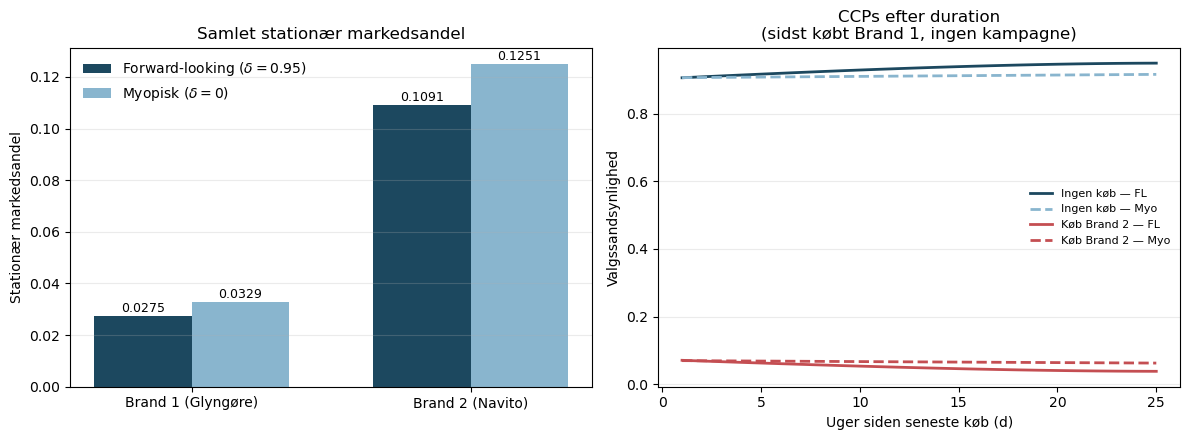

In [31]:
# ── Stationær fordeling via power iteration ───────────────────────────────────
def compute_stationary(P, trans, n_iter=5_000, tol=1e-10):
    """Stationær fordeling over (J, D_MAX+1, N_PROMO)."""
    mu = np.full((J, D_MAX + 1, N_PROMO), 1.0 / (J * (D_MAX + 1) * N_PROMO))
    for _ in range(n_iter):
        mu_new = np.zeros_like(mu)
        flow0   = mu * P[..., 0]
        shifted = np.zeros_like(flow0)
        shifted[:, 1:,    :] = flow0[:, :-1, :]
        shifted[:, D_MAX, :] += flow0[:, D_MAX, :]
        mu_new += shifted @ trans
        for j in range(J):
            mu_new[j, 1, :] += (mu * P[..., j + 1]).sum(axis=(0, 1)) @ trans
        mu_new /= mu_new.sum()
        if np.max(np.abs(mu_new - mu)) < tol:
            return mu_new
        mu = mu_new
    return mu


# ── Myopiske CCPs: statisk logit (delta=0) ────────────────────────────────────
def compute_myopic_ccps(alpha, gamma, beta_sc, beta_dep):
    """CCPs for myopisk forbruger — ingen continuation value."""
    dur = np.arange(D_MAX + 1, dtype=float)
    Q   = np.zeros((J, D_MAX + 1, N_PROMO, N_CHOICES))
    Q[..., 0] = (alpha[:, None, None]
                 - beta_dep[:, None, None] * dur[None, :, None])
    for j in range(J):
        Q[..., j + 1] = (
            alpha[j]
            - gamma * PRICE_BY_PROMO[:, j][None, None, :]
            - beta_sc[:, j][:, None, None]
        )
    w = np.exp(Q - Q.max(axis=3, keepdims=True))
    return w / w.sum(axis=3, keepdims=True)


# ── Forward-looking brand shares ──────────────────────────────────────────────
mu_fl     = compute_stationary(P_hat, PROMO_TRANS)
shares_fl = np.array([(mu_fl * P_hat[..., j]).sum() for j in range(N_CHOICES)])


# ── Myopiske brand shares ─────────────────────────────────────────────────────
alpha_hat    = make_alpha(ALPHA_1_HAT, ALPHA_2_HAT)
beta_dep_hat = make_beta_dep(BETA_DEP_HAT)
beta_sc_hat  = make_beta_sc(BETA_SC_HAT)

P_myo     = compute_myopic_ccps(alpha_hat, GAMMA_HAT, beta_sc_hat, beta_dep_hat)
mu_myo    = compute_stationary(P_myo, PROMO_TRANS)
shares_myo = np.array([(mu_myo * P_myo[..., j]).sum() for j in range(N_CHOICES)])


# ── Resultattabel ─────────────────────────────────────────────────────────────
labels = ["Ingen køb", "Brand 1 (Glyngøre)", "Brand 2 (Navito)"]
print("Forward-looking (delta=0.95) vs. myopisk (delta=0)")
print(f"\n  {'Valg':<22} {'Forward-looking':>16} {'Myopisk':>10} {'Forskel':>10} {'%-ændring':>11}")
print("  " + "-" * 72)
for j, lbl in enumerate(labels):
    diff = shares_myo[j] - shares_fl[j]
    pct  = diff / shares_fl[j] * 100 if shares_fl[j] > 0 else float("nan")
    print(f"  {lbl:<22} {shares_fl[j]:>16.4f} {shares_myo[j]:>10.4f} {diff:>+10.4f} {pct:>+10.1f}%")

print(f"\nParametre ved MLE:")
print(f"  beta_sc  = {BETA_SC_HAT:.4f}  (switching cost)")
print(f"  beta_dep = {BETA_DEP_HAT:.4f}  (depreciation)")
print(f"  delta    = {DELTA}          (diskonteringsfaktor)")


# ── Plot 1: Markedsandele ─────────────────────────────────────────────────────
x, w = np.arange(J), 0.35
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

COLOR_FL  = "#1c485f"
COLOR_MYO = "#89b5ce"

ax = axes[0]
ax.bar(x - w/2, shares_fl[1:],  w, label=f"Forward-looking ($\\delta={DELTA}$)", color=COLOR_FL)
ax.bar(x + w/2, shares_myo[1:], w, label="Myopisk ($\\delta=0$)",               color=COLOR_MYO)
for i, (fl, myo) in enumerate(zip(shares_fl[1:], shares_myo[1:])):
    ax.text(i - w/2, fl  + 0.0003, f"{fl:.4f}",  ha="center", va="bottom", fontsize=9)
    ax.text(i + w/2, myo + 0.0003, f"{myo:.4f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(["Brand 1 (Glyngøre)", "Brand 2 (Navito)"])
ax.set_ylabel("Stationær markedsandel")
ax.set_title("Samlet stationær markedsandel")
ax.legend(frameon=False); ax.grid(axis="y", alpha=0.25)


# ── Plot 2: CCPs efter duration (l=1, e=0) ───────────────────────────────────
ax = axes[1]
dur_vals = np.arange(1, D_MAX + 1)
# Betinget på l=0 (sidst købt Brand 1), e=0 (ingen kampagne)
ax.plot(dur_vals, P_hat[0, 1:, 0, 0],  lw=2, color=COLOR_FL,  label="Ingen køb — FL")
ax.plot(dur_vals, P_myo[0, 1:, 0, 0],  lw=2, color=COLOR_MYO, label="Ingen køb — Myo", ls="--")
ax.plot(dur_vals, P_hat[0, 1:, 0, 2],  lw=2, color="#c44e52", label="Køb Brand 2 — FL")
ax.plot(dur_vals, P_myo[0, 1:, 0, 2],  lw=2, color="#c44e52", label="Køb Brand 2 — Myo", ls="--")
ax.set_xlabel("Uger siden seneste køb (d)")
ax.set_ylabel("Valgssandsynlighed")
ax.set_title("CCPs efter duration\n(sidst købt Brand 1, ingen kampagne)")
ax.legend(frameon=False, fontsize=8); ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.savefig("nfxp_empirical_myopic_vs_fl.pdf", bbox_inches="tight")
plt.show()


## 13. Choice probabilities over time — forward simulation

For hvert δ ∈ {0, 0.25, 0.5, 0.75, 0.95}: start alle forbrugere i en
fælles starttilstand (uniform over alle tilstande) og simulér 60 uger frem
med MLE-estimater. Y-aksen er den **ubetingede** sandsynlighed for at købe
hvert brand i uge $t$.


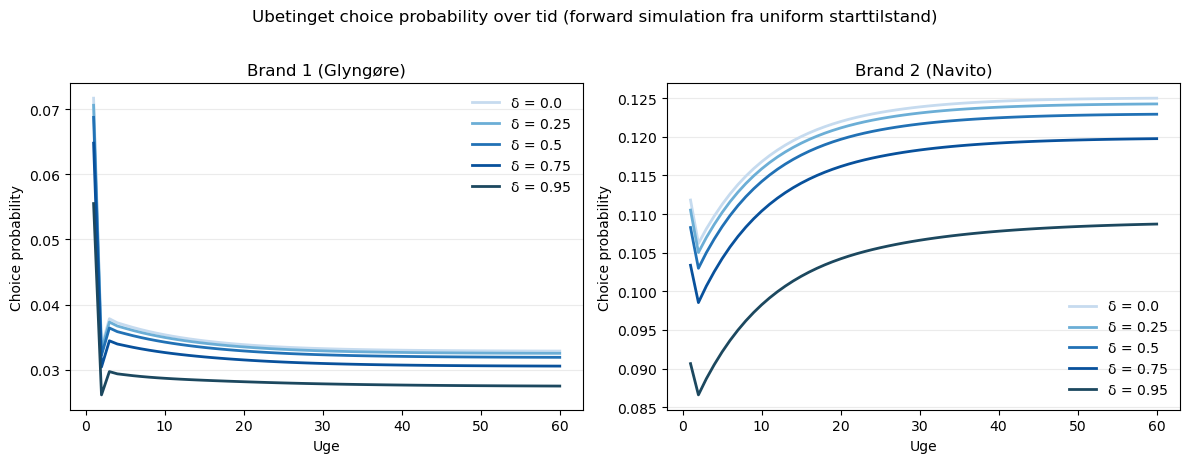

In [32]:
# ── Lokal VFI med variabel delta ─────────────────────────────────────────────
def _solve_vfi_delta(alpha, gamma, beta_sc, beta_dep, delta,
                     tol=1e-9, max_iter=2_000):
    dur_idx  = np.arange(D_MAX + 1)
    duration = dur_idx.astype(float)
    next_dur = np.minimum(dur_idx + 1, D_MAX)
    no_purch = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    Q = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    V = np.zeros((J, D_MAX + 1, N_PROMO))
    for _ in range(max_iter):
        EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
              ).reshape(J, D_MAX + 1, N_PROMO)
        Q[..., 0] = no_purch[:, :, None] + delta * EV[:, next_dur, :]
        for j in range(J):
            Q[..., j + 1] = (
                alpha[j]
                - gamma * PRICE_BY_PROMO[:, j][None, None, :]
                - beta_sc[:, j][:, None, None]
                + delta * EV[j, 1, :][None, None, :]
            )
        q_max = Q.max(axis=3)
        V_new = q_max + np.log(np.exp(Q - q_max[..., None]).sum(axis=3))
        if np.max(np.abs(V_new - V)) < tol:
            return V_new
        V = V_new
    return V


def _ccps_delta(alpha, gamma, beta_sc, beta_dep, delta):
    dur_idx  = np.arange(D_MAX + 1)
    duration = dur_idx.astype(float)
    next_dur = np.minimum(dur_idx + 1, D_MAX)
    no_purch = alpha[:, None] - beta_dep[:, None] * duration[None, :]
    V  = _solve_vfi_delta(alpha, gamma, beta_sc, beta_dep, delta)
    EV = (V.reshape(J * (D_MAX + 1), N_PROMO) @ PROMO_TRANS.T
          ).reshape(J, D_MAX + 1, N_PROMO)
    Q  = np.empty((J, D_MAX + 1, N_PROMO, N_CHOICES))
    Q[..., 0] = no_purch[:, :, None] + delta * EV[:, next_dur, :]
    for j in range(J):
        Q[..., j + 1] = (
            alpha[j]
            - gamma * PRICE_BY_PROMO[:, j][None, None, :]
            - beta_sc[:, j][:, None, None]
            + delta * EV[j, 1, :][None, None, :]
        )
    w = np.exp(Q - Q.max(axis=3, keepdims=True))
    return w / w.sum(axis=3, keepdims=True)


def _forward_simulate(P, trans, T=60):
    """
    Simulér T uger fra uniform starttilstand.
    Returnerer choice_shares shape (T, N_CHOICES):
      shares[t, c] = ubetinget P(valg=c i uge t).
    """
    mu = np.full((J, D_MAX + 1, N_PROMO), 1.0 / (J * (D_MAX + 1) * N_PROMO))
    shares = np.zeros((T, N_CHOICES))
    for t in range(T):
        # Ubetinget sandsynlighed for hvert valg denne uge
        for c in range(N_CHOICES):
            shares[t, c] = (mu * P[..., c]).sum()
        # Opdatér fordeling (samme overgang som compute_stationary)
        mu_new = np.zeros_like(mu)
        flow0   = mu * P[..., 0]
        shifted = np.zeros_like(flow0)
        shifted[:, 1:,    :] = flow0[:, :-1, :]
        shifted[:, D_MAX, :] += flow0[:, D_MAX, :]
        mu_new += shifted @ trans
        for j in range(J):
            mu_new[j, 1, :] += (mu * P[..., j + 1]).sum(axis=(0, 1)) @ trans
        mu /= mu.sum()  # numerisk stabilitet
        mu = mu_new
    return shares


# ── MLE-parametre ─────────────────────────────────────────────────────────────
alpha_hat_d    = make_alpha(ALPHA_1_HAT, ALPHA_2_HAT)
beta_dep_hat_d = make_beta_dep(BETA_DEP_HAT)
beta_sc_hat_d  = make_beta_sc(BETA_SC_HAT)

DELTA_VALS  = [0.0, 0.25, 0.5, 0.75, 0.95]
DELTA_COLS  = ["#c6dbef", "#6baed6", "#2171b5", "#08519c", "#1c485f"]
BRAND_NAMES = ["Brand 1 (Glyngøre)", "Brand 2 (Navito)"]
T           = 60
weeks       = np.arange(1, T + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for delta_val, color in zip(DELTA_VALS, DELTA_COLS):
    P_d    = _ccps_delta(alpha_hat_d, GAMMA_HAT, beta_sc_hat_d,
                         beta_dep_hat_d, delta_val)
    shares = _forward_simulate(P_d, PROMO_TRANS, T=T)
    for b, ax in enumerate(axes):
        ax.plot(weeks, shares[:, b + 1], color=color, lw=2,
                label=f"\u03b4 = {delta_val}")

for ax, bname in zip(axes, BRAND_NAMES):
    ax.set_xlabel("Uge")
    ax.set_ylabel("Choice probability")
    ax.set_title(bname)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Ubetinget choice probability over tid (forward simulation fra uniform starttilstand)",
    y=1.02,
)
plt.tight_layout()
plt.savefig("nfxp_empirical_delta_comparison.pdf", bbox_inches="tight")
plt.show()


## 14. Choice probability efter uger siden seneste køb (kundeniveau)

To-trins-gennemsnit for at give hver kunde lige vægt:
1. For hvert par (kunde, duration) beregnes den gennemsnitlige forudsagte sandsynlighed.
2. Gennemsnittet over kunder beregnes for hver duration.


Unikke kunder          : 42,815
Køb i alt              : 258,211
Gns. køb per kunde     : 6.03


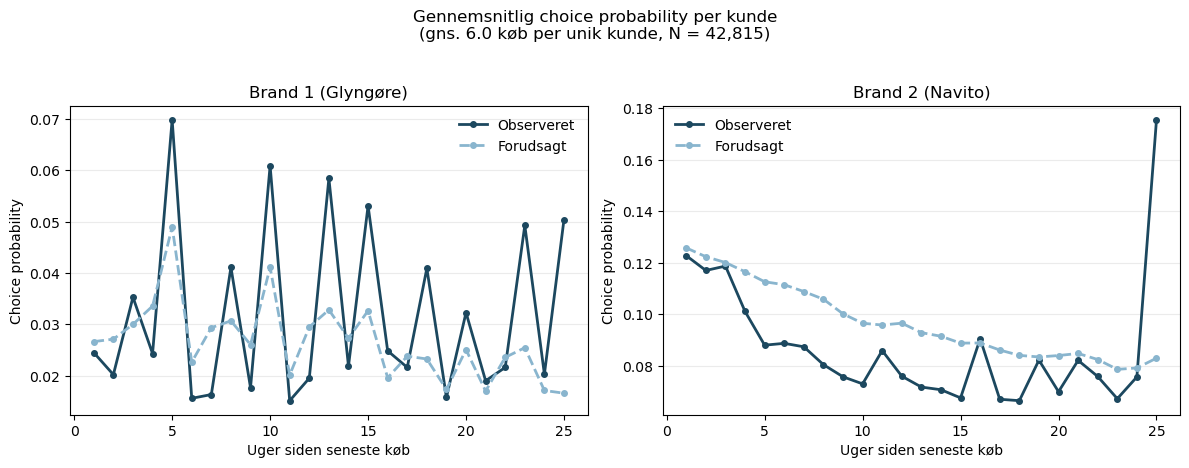

In [33]:
# ── Tilføj observerede indikatorer og forudsagte CCP'er ──────────────────────
_pnl = panel_df.copy()
_pnl["actual_b1"] = (_pnl["Y"] == 1).astype(float)
_pnl["actual_b2"] = (_pnl["Y"] == 2).astype(float)
_pnl["pred_b1"]   = P_hat[
    _pnl["L"].to_numpy(dtype=int) - 1,
    _pnl["D"].to_numpy(dtype=int),
    _pnl["E_IDX"].to_numpy(dtype=int),
    1,
]
_pnl["pred_b2"]   = P_hat[
    _pnl["L"].to_numpy(dtype=int) - 1,
    _pnl["D"].to_numpy(dtype=int),
    _pnl["E_IDX"].to_numpy(dtype=int),
    2,
]

# ── Trin 1: gennemsnit per (kunde, duration) ──────────────────────────────────
_cols    = ["actual_b1", "actual_b2", "pred_b1", "pred_b2"]
_hh_dur  = _pnl.groupby(["Customer_ID", "D"])[_cols].mean().reset_index()

# ── Trin 2: gennemsnit over kunder for hver duration ─────────────────────────
_dur_avg = _hh_dur.groupby("D")[_cols].mean().reset_index()

# ── Antal køb per unik kunde ──────────────────────────────────────────────────
_n_cust  = _pnl["Customer_ID"].nunique()
_n_purch = int((_pnl["Y"] > 0).sum())
_avg_purch_per_cust = _n_purch / _n_cust

print(f"Unikke kunder          : {_n_cust:,}")
print(f"Køb i alt              : {_n_purch:,}")
print(f"Gns. køb per kunde     : {_avg_purch_per_cust:.2f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
COLOR_OBS  = "#1c485f"
COLOR_PRED = "#89b5ce"
BRAND_NAMES = ["Brand 1 (Glyngøre)", "Brand 2 (Navito)"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for b, (ax, bname) in enumerate(zip(axes, BRAND_NAMES)):
    ax.plot(_dur_avg["D"], _dur_avg[f"actual_b{b+1}"],
            color=COLOR_OBS,  lw=2, marker="o", ms=4, label="Observeret")
    ax.plot(_dur_avg["D"], _dur_avg[f"pred_b{b+1}"],
            color=COLOR_PRED, lw=2, marker="o", ms=4, ls="--", label="Forudsagt")
    ax.set_xlabel("Uger siden seneste køb")
    ax.set_ylabel("Choice probability")
    ax.set_title(bname)
    ax.legend(frameon=False)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    f"Gennemsnitlig choice probability per kunde\n"
    f"(gns. {_avg_purch_per_cust:.1f} køb per unik kunde, N = {_n_cust:,})",
    y=1.03,
)
plt.tight_layout()
plt.savefig("nfxp_empirical_hh_choice_prob_by_duration.pdf", bbox_inches="tight")
plt.show()
